## Dataset Description, Audit, & Exploratory Data Analysis (EDA)

### Load dataset

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define file name
file_name = "/content/Depression_Severity_Levels_Dataset.csv"

# Verify file presence
if not os.path.exists(file_name):
    raise FileNotFoundError(f"Could not find '{file_name}' in the current directory. Please ensure it is uploaded.")

# 1. Load the Dataset
print("=== PHASE 1: LOADING DATASET ===")
df = pd.read_csv(file_name, engine='python')
print(f"Dataset successfully loaded. Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
print(f"Columns discovered: {list(df.columns)}")
df

=== PHASE 1: LOADING DATASET ===
Dataset successfully loaded. Total Rows: 41873 | Total Columns: 2
Columns discovered: ['text', 'label']


,text,label
0,"He said he had not felt that way before, sugge...",mild
1,"Hey there r/assistance, Not sure if this is th...",minimum
2,My mom then hit me with the newspaper and it s...,minimum
3,"until i met my new boyfriend, he is amazing, h...",mild
4,October is Domestic Violence Awareness Month a...,moderate
...,...,...
41868,You cannot fix your children and you cannot pl...,minimum
41869,Awakenings App - NEW CONTENT now available! ...,minimum
41870,Spend less time worrying about what others thi...,minimum
41871,Trust is the belief that you can get through a...,minimum


### Structural integrity audit

In [ ]:
print("\n=== DATA AUDIT: DETECTING ANOMALIES ===")
null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts)

duplicate_count = df.duplicated().sum()
print(f"\nExact duplicate rows discovered: {duplicate_count}")


=== DATA AUDIT: DETECTING ANOMALIES ===
Missing values per column:
text     14
label     0
dtype: int64

Exact duplicate rows discovered: 6406


### Confirm class balance

In [ ]:
print("\n=== TARGET CLASS DISTRIBUTION ===")
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100
distribution_summary = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct})
print(distribution_summary)


=== TARGET CLASS DISTRIBUTION ===
          Count  Percentage (%)
label                          
severe    11176       26.690230
mild      10661       25.460320
minimum   10556       25.209562
moderate   9480       22.639887


### Initial distribution visualization

/tmp/ipykernel_3739/1619411495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="muted")


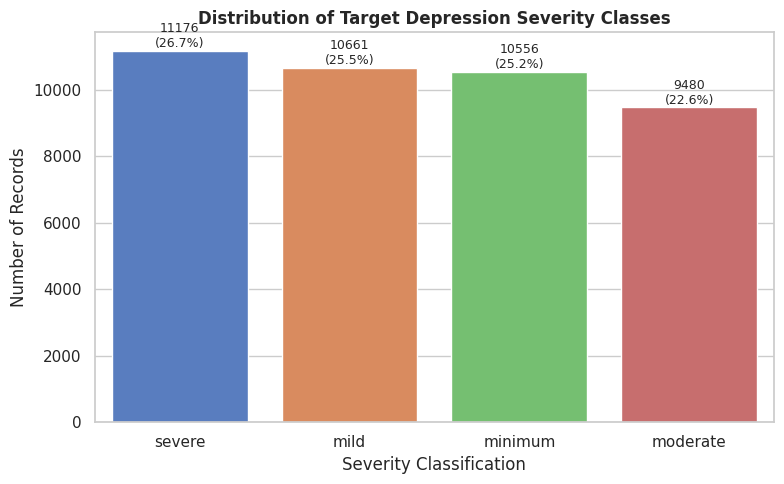

In [ ]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.barplot(x=class_counts.index, y=class_counts.values, palette="muted")
plt.title("Distribution of Target Depression Severity Classes", fontsize=12, fontweight='bold')
plt.xlabel("Severity Classification")
plt.ylabel("Number of Records")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + (max(class_counts.values) * 0.01), f"{v}\n({class_pct.values[i]:.1f}%)", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Text length profiling

=== DESCRIPTIVE STATISTICS FOR TEXT LENGTH (WORDS) ===
                mean         std  min    50%     max
label                                               
mild      176.998499  188.829421  1.0  121.0  2612.0
minimum    45.804436   65.942701  1.0   22.0  1207.0
moderate  105.378338  168.231154  1.0   46.0  2639.0
severe    155.730315  188.116327  1.0   99.0  5248.0


/tmp/ipykernel_3739/2763643850.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile, x='label', y='word_count', palette="Set2")


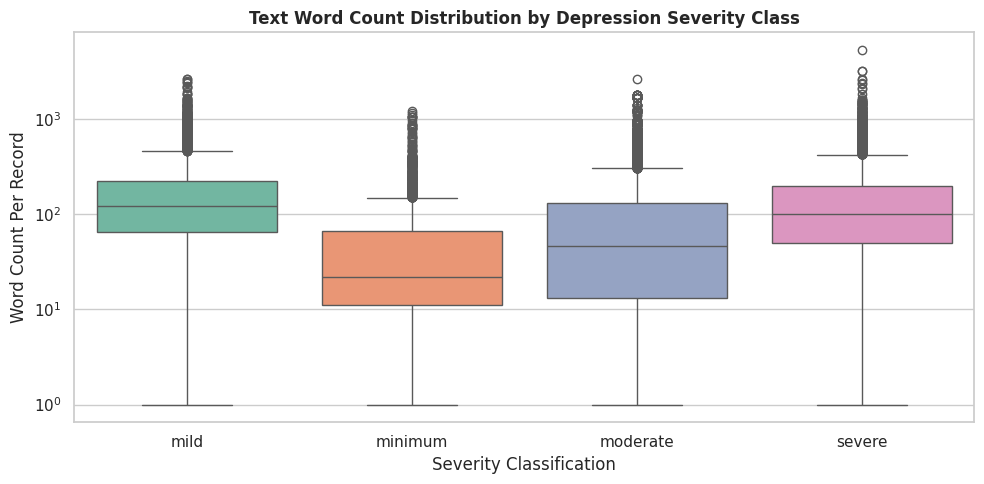

In [ ]:
# Create word count metrics for the raw text entries
df_profile = df.dropna(subset=['text', 'label']).copy()
df_profile['word_count'] = df_profile['text'].apply(lambda x: len(str(x).split()))

print("=== DESCRIPTIVE STATISTICS FOR TEXT LENGTH (WORDS) ===")
stats = df_profile.groupby('label')['word_count'].describe()[['mean', 'std', 'min', '50%', 'max']]
print(stats)

# Visualizing text length distributions per class
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_profile, x='label', y='word_count', palette="Set2")
plt.title("Text Word Count Distribution by Depression Severity Class", fontsize=12, fontweight='bold')
plt.xlabel("Severity Classification")
plt.ylabel("Word Count Per Record")
plt.yscale('log') # Log scale handles massive outliers cleanly
plt.tight_layout()
plt.show()

### : Data Preprocessing & Stratified Splitting

In [ ]:
import re
import nltk
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

# 1. Download necessary text processing resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("=== PHASE 2: DATA PREPROCESSING & CLEANING ===")

=== PHASE 2: DATA PREPROCESSING & CLEANING ===


### Handle missing rows and duplicates

In [ ]:
# Drop the missing label row
df_clean = df.dropna(subset=['label']).copy()

# Drop exact duplicate rows to protect test set integrity
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['text']).copy()
dropped_rows = initial_rows - len(df_clean)
print(f"Dropped {dropped_rows} duplicate rows. Remaining unique rows: {len(df_clean)}")

Dropped 9460 duplicate rows. Remaining unique rows: 32413


### Clean dataset texts

In [ ]:
# 2. Define the Preprocessing Engine
def preprocess_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs and web links
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove punctuation and non-alphabetic special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization by space splitting
    words = text.split()

    # Filter out standard English stop-words
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # Apply lemmatization to normalize word roots
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]

    return " ".join(lemmatized_words)

# Apply cleaning pipeline to the text column
print("Applying normalization, stop-word removal, and lemmatization...")
df_clean['processed_text'] = df_clean['text'].apply(preprocess_text)

# Eliminate any rows that became completely empty strings after text cleaning
df_clean = df_clean[df_clean['processed_text'].str.strip() != ''].copy()
print(f"Final aligned clean dataset row count: {len(df_clean)}")

Applying normalization, stop-word removal, and lemmatization...
Final aligned clean dataset row count: 32371


In [ ]:
df_clean.head()

,text,label,processed_text
0,"He said he had not felt that way before, sugge...",mild,said felt way suggeted go rest trigger ahead y...
1,"Hey there r/assistance, Not sure if this is th...",minimum,hey rassistance sure right place post go im cu...
2,My mom then hit me with the newspaper and it s...,minimum,mom hit newspaper shocked would know dont like...
3,"until i met my new boyfriend, he is amazing, h...",mild,met new boyfriend amazing kind sweet good stud...
4,October is Domestic Violence Awareness Month a...,moderate,october domestic violence awareness month dome...


### Data partitioning

In [ ]:
# 3. Stratified Dataset Splitting
print("\n=== EXECUTING STRATIFIED SAMPLING ===")
X = df_clean['processed_text'].values
y = df_clean['label'].values

RANDOM_SEED = 42

# First Split: 70% Training, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)

# Second Split: Split the 30% Temporary set equally (15% Validation, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print("\nDataset split successfully completed:")
print(f"  - Training Set Vector Shape:   {X_train.shape} | Labels: {y_train.shape}")
print(f"  - Validation Set Vector Shape: {X_val.shape} | Labels: {y_val.shape}")
print(f"  - Testing Set Vector Shape:    {X_test.shape} | Labels: {y_test.shape}")


=== EXECUTING STRATIFIED SAMPLING ===

Dataset split successfully completed:
  - Training Set Vector Shape:   (22659,) | Labels: (22659,)
  - Validation Set Vector Shape: (4856,) | Labels: (4856,)
  - Testing Set Vector Shape:    (4856,) | Labels: (4856,)


## Feature Engineering for Baseling Hybrid Model

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 1. Initialize and fit the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

print("Vectorizing text inputs into TF-IDF sparse matrices...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Matrix Dimensions -> Train: {X_train_tfidf.shape} | Test: {X_test_tfidf.shape}")

Vectorizing text inputs into TF-IDF sparse matrices...
TF-IDF Matrix Dimensions -> Train: (22659, 10000) | Test: (4856, 10000)


## Training Baseline Model

In [ ]:
# 1. Train Constituent Component A: Logistic Regression (The Probability Generator)
print("\n[Step 1/2] Training Hybrid Component A (Logistic Regression)...")
start_time = time.time()
meta_lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
meta_lr.fit(X_train_tfidf, y_train)

# Generate Class Probabilities to serve as new engineered meta-features
train_probs = meta_lr.predict_proba(X_train_tfidf)
test_probs  = meta_lr.predict_proba(X_test_tfidf)

# 2. Hybridization Layer: Augment raw TF-IDF spaces with the probability distributions
import scipy.sparse as sp
X_train_hybrid = sp.hstack((X_train_tfidf, train_probs), format='csr')
X_test_hybrid  = sp.hstack((X_test_tfidf, test_probs), format='csr')

# 3. Train Constituent Component B: Linear SVM on the Hybridized Feature Space
print("[Step 2/2] Training Hybrid Component B (Linear SVM) on Augmented Features...")
hybrid_svm = LinearSVC(C=1.0, random_state=42, max_iter=2000)
hybrid_svm.fit(X_train_hybrid, y_train)

hybrid_train_time = time.time() - start_time
print(f"Unified Hybrid Baseline Model trained successfully in {hybrid_train_time:.2f} seconds.")


[Step 1/2] Training Hybrid Component A (Logistic Regression)...
[Step 2/2] Training Hybrid Component B (Linear SVM) on Augmented Features...
Unified Hybrid Baseline Model trained successfully in 14.91 seconds.


### Evaluation of Baseline Hybrid Model


=== Evaluating Hybrid Baseline Model on Test Set ===

--- MODEL 1 (TRUE HYBRID BASELINE) CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        mild     0.6490    0.6656    0.6572      1597
     minimum     0.7246    0.7246    0.7246       944
    moderate     0.6276    0.6224    0.6250       715
      severe     0.6339    0.6200    0.6269      1600

    accuracy                         0.6557      4856
   macro avg     0.6588    0.6581    0.6584      4856
weighted avg     0.6555    0.6557    0.6556      4856



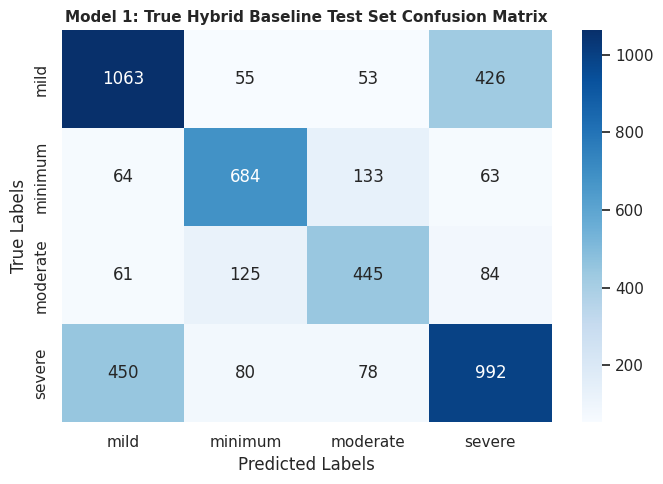

In [ ]:
print("\n=== Evaluating Hybrid Baseline Model on Test Set ===")
y_pred_hybrid = hybrid_svm.predict(X_test_hybrid)

print("\n--- MODEL 1 (TRUE HYBRID BASELINE) CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_hybrid, digits=4))

# Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_hybrid)
labels = sorted(list(np.unique(y_test)))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Model 1: True Hybrid Baseline Test Set Confusion Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

### Feature Engineering for GRU Model

In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("=== PHASE 4: GRU FEATURE ENGINEERING & TRAINING ===")

=== PHASE 4: GRU FEATURE ENGINEERING & TRAINING ===


In [ ]:
# 1. Encode Target Strings into Numeric Integers (0, 1, 2, 3)
label_encoder_gru = LabelEncoder()
y_train_gru = label_encoder_gru.fit_transform(y_train)
y_val_gru   = label_encoder_gru.transform(y_val)
y_test_gru  = label_encoder_gru.transform(y_test)

# 2. Tokenize and Vectorize Text Sequences
MAX_WORDS = 20000       # Top vocabulary size limit
MAX_LEN = 256           # Sequence length cap from Phase 1 audit

tokenizer_gru = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_gru.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer_gru.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_val_seq   = pad_sequences(tokenizer_gru.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tokenizer_gru.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

print(f"Text tokenized into sequence matrix shape: {X_train_seq.shape}")

Text tokenized into sequence matrix shape: (22659, 256)


## Training GRU Model

In [ ]:
# 1. Construct the GRU Neural Network Architecture
EMBEDDING_DIM = 128

model_gru = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    GRU(units=64, dropout=0.2, recurrent_dropout=0.0, return_sequences=False),
    Dropout(0.3),
    Dense(units=32, activation='relu'),
    Dropout(0.2),
    Dense(units=4, activation='softmax') # 4-class multi-classification layer
])

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2. Train the Model
print("\nTraining Model 2 (Gated Recurrent Unit)...")
start_time = time.time()

# Using early stopping to capture the best validation state and mitigate overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model_gru.fit(
    X_train_seq, y_train_gru,
    validation_data=(X_val_seq, y_val_gru),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

gru_train_time = time.time() - start_time
print(f"\nGRU training finished in {gru_train_time:.2f} seconds.")


Training Model 2 (Gated Recurrent Unit)...
Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3317 - loss: 1.3401 - val_accuracy: 0.3322 - val_loss: 1.3316
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3298 - loss: 1.3323 - val_accuracy: 0.3334 - val_loss: 1.3297
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3346 - loss: 1.3259 - val_accuracy: 0.3293 - val_loss: 1.3299
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3376 - loss: 1.3185 - val_accuracy: 0.3289 - val_loss: 1.3337

GRU training finished in 33.06 seconds.


## Evaluation of GRU Model

In [ ]:
print("\n=== Evaluating GRU Model on Test Set ===")
y_pred_probs = model_gru.predict(X_test_seq)
y_pred_gru = np.argmax(y_pred_probs, axis=1)

# Convert indices back to original string classes for equal comparison reports
y_pred_labels = label_encoder_gru.inverse_transform(y_pred_gru)

print("\n--- MODEL 2 (GRU) CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_labels, digits=4))


=== Evaluating GRU Model on Test Set ===
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

--- MODEL 2 (GRU) CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        mild     0.4588    0.0244    0.0464      1597
     minimum     0.0000    0.0000    0.0000       944
    moderate     0.0000    0.0000    0.0000       715
      severe     0.3280    0.9781    0.4913      1600

    accuracy                         0.3303      4856
   macro avg     0.1967    0.2506    0.1344      4856
weighted avg     0.2590    0.3303    0.1771      4856



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Optimized GRU

In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, GRU, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("=== PHASE 4 (OPTIMIZED): GRU SEQUENCE CORRECTION ===")

# 1. Re-vectorize using PRE-padding to protect the sequential gradient
MAX_WORDS = 20000
MAX_LEN = 256

tokenizer_gru = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_gru.fit_on_texts(X_train)

# Switched padding and truncating from 'post' to 'pre'
X_train_seq = pad_sequences(tokenizer_gru.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='pre', truncating='pre')
X_val_seq   = pad_sequences(tokenizer_gru.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_seq  = pad_sequences(tokenizer_gru.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='pre', truncating='pre')

print(f"Text tokenized into pre-padded sequence shape: {X_train_seq.shape}")

# 2. Build the Upgraded GRU Network
EMBEDDING_DIM = 128

model_gru_opt = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    # SpatialDropout1D drops entire 1D feature maps to prevent token-level overfitting
    SpatialDropout1D(0.2),
    GRU(units=64, dropout=0.2, recurrent_dropout=0.0, return_sequences=False),
    Dropout(0.3),
    Dense(units=32, activation='relu'),
    Dropout(0.2),
    Dense(units=4, activation='softmax')
])

model_gru_opt.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# 3. Train with Early Stopping monitoring validation loss
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\nTraining Model 2 (Optimized GRU)...")
start_time = time.time()

history_opt = model_gru_opt.fit(
    X_train_seq, y_train_gru,
    validation_data=(X_val_seq, y_val_gru),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

gru_train_time = time.time() - start_time
print(f"\nOptimized GRU training finished in {gru_train_time:.2f} seconds.")

# 4. Evaluation Loop
print("\n=== Evaluating Optimized GRU Model on Test Set ===")
y_pred_probs_opt = model_gru_opt.predict(X_test_seq)
y_pred_gru_opt = np.argmax(y_pred_probs_opt, axis=1)

y_pred_labels_opt = label_encoder_gru.inverse_transform(y_pred_gru_opt)

print("\n--- MODEL 2 (OPTIMIZED GRU) CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_labels_opt, digits=4))

=== PHASE 4 (OPTIMIZED): GRU SEQUENCE CORRECTION ===
Text tokenized into pre-padded sequence shape: (22659, 256)

Training Model 2 (Optimized GRU)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


355/355 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5280 - loss: 0.9935 - val_accuracy: 0.6514 - val_loss: 0.7934
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.6955 - loss: 0.7207 - val_accuracy: 0.6888 - val_loss: 0.7439
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7616 - loss: 0.5915 - val_accuracy: 0.6798 - val_loss: 0.7828
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7998 - loss: 0.5035 - val_accuracy: 0.6771 - val_loss: 0.8519

Optimized GRU training finished in 37.19 seconds.

=== Evaluating Optimized GRU Model on Test Set ===
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

--- MODEL 2 (OPTIMIZED GRU) CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        mild     0.7257    0.6775    0.7008      1597
     minimum     0.6781    0.7987    0.7335       944
    moderate     0.6941    0.6252    0.6578       715
      severe     0.6830    0.6869    0.6849      1600

    accuracy          

Evaluation Visualisations of GRU Model

=== GENERATING OPTIMIZED GRU PERFORMANCE VISUALIZATIONS ===


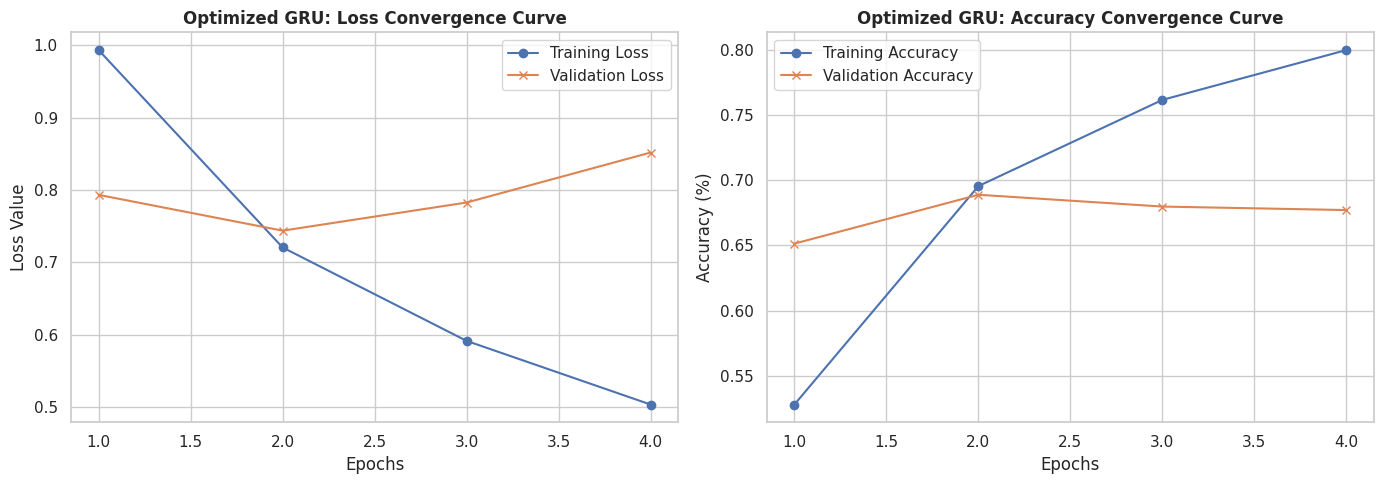

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=== GENERATING OPTIMIZED GRU PERFORMANCE VISUALIZATIONS ===")

# 1. Plot Training & Validation Learning Curves
epochs_range = range(1, len(history_opt.history['loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_opt.history['loss'], marker='o', label='Training Loss')
plt.plot(epochs_range, history_opt.history['val_loss'], marker='x', label='Validation Loss')
plt.title('Optimized GRU: Loss Convergence Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_opt.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(epochs_range, history_opt.history['val_accuracy'], marker='x', label='Validation Accuracy')
plt.title('Optimized GRU: Accuracy Convergence Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

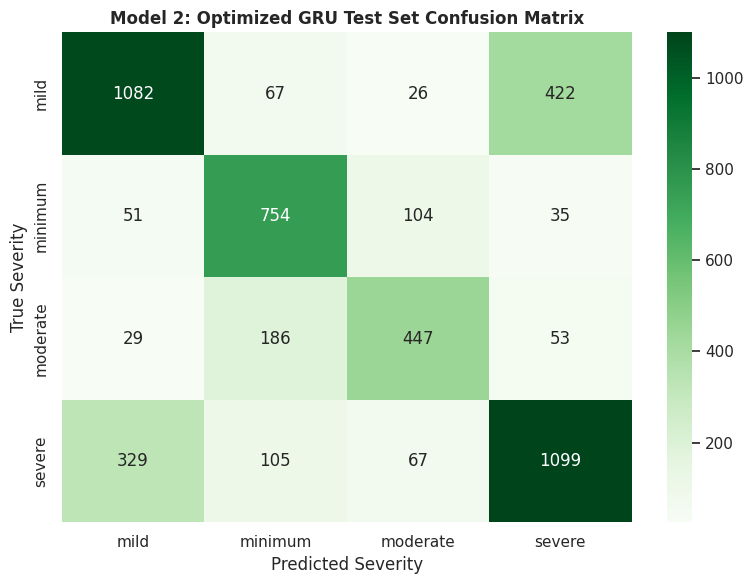

In [ ]:
# 2. Generate and Plot Confusion Matrix
gru_cm = confusion_matrix(y_test, y_pred_labels_opt)
gru_labels = sorted(list(np.unique(y_test)))

plt.figure(figsize=(8, 6))
sns.heatmap(gru_cm, annot=True, fmt='d', cmap='Greens', xticklabels=gru_labels, yticklabels=gru_labels)
plt.title('Model 2: Optimized GRU Test Set Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.tight_layout()
plt.show()

## Feature Engineering for Transformer Model - DistilBERT

In [ ]:
# 1. Install Hugging Face Transformers ecosystem
!pip install -q transformers[torch] datasets accelerate

import time
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from sklearn.metrics import classification_report

print("=== PHASE 5: INITIALIZING DISTILBERT PIPELINE ===")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device.upper()} (Verify this reads CUDA!)")

=== PHASE 5: INITIALIZING DISTILBERT PIPELINE ===
Using execution device: CUDA (Verify this reads CUDA!)


In [ ]:
# 2. Encode labels into standard ordered integers matching model heads
label_encoder_bert = LabelEncoder()
y_train_bert = label_encoder_bert.fit_transform(y_train)
y_val_bert   = label_encoder_bert.transform(y_val)
y_test_bert  = label_encoder_bert.transform(y_test)
num_classes  = len(label_encoder_bert.classes_)

# 3. Load DistilBERT Tokenizer
model_name = "distilbert-base-uncased"
print(f"\nDownloading tokenizer engine for: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 4. Tokenization Function mapping text lists to attention dictionaries
def tokenize_function(examples):
    # Max length 256 maintains mathematical alignment with our GRU evaluation
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=256)

# Construct HuggingFace Datasets directly from our split numpy arrays
train_ds = Dataset.from_dict({'text': X_train, 'label': y_train_bert})
val_ds   = Dataset.from_dict({'text': X_val, 'label': y_val_bert})
test_ds  = Dataset.from_dict({'text': X_test, 'label': y_test_bert})

print("Encoding text splits into context token tensors...")
train_tokenized = train_ds.map(tokenize_function, batched=True)
val_tokenized   = val_ds.map(tokenize_function, batched=True)
test_tokenized  = test_ds.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Encoding text splits into context token tensors...


Map:   0%|          | 0/22659 [00:00<?, ? examples/s]

Map:   0%|          | 0/4856 [00:00<?, ? examples/s]

Map:   0%|          | 0/4856 [00:00<?, ? examples/s]

### Configuring and training transformer model

In [ ]:
# 1. Initialize Pre-trained Transformer Model Head
print(f"\nLoading pre-trained weights for {model_name}...")
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)
model_bert.to(device)

# 2. Configure Optimization Hyperparameters
training_args = TrainingArguments(
    output_dir="./distilbert_depression_results",
    learning_rate=2e-5,              # Conservative learning rate preserves pre-trained weights
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,              # 2 epochs is optimal to prevent transformer overfitting
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    logging_steps=100,
    report_to="none"                 # Disables third-party logging pop-ups
)

# Helper metric computer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = np.sum(preds == labels) / len(labels)
    return {"accuracy": acc}

# Initialize Trainer Engine
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

print("\n🚀 Starting Transformer Fine-Tuning. Watch the log values drop below...")
start_time = time.time()
trainer.train()
bert_train_time = time.time() - start_time
print(f"\nDistilBERT Fine-Tuning finished in {bert_train_time:.2f} seconds.")


Loading pre-trained weights for distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🚀 Starting Transformer Fine-Tuning. Watch the log values drop below...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.695104,0.696785,0.699959
2,0.648476,0.664624,0.725494


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT Fine-Tuning finished in 1052.92 seconds.


## Evaluation of Transformer Model

In [ ]:
# Collect Predictions on Holdout Test Set
print("\n=== Evaluating DistilBERT on Test Set ===")
predictions = trainer.predict(test_tokenized)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

y_pred_labels_bert = label_encoder_bert.inverse_transform(y_pred_bert)

print("\n--- MODEL 3 (DISTILBERT) CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_labels_bert, digits=4))


=== Evaluating DistilBERT on Test Set ===



--- MODEL 3 (DISTILBERT) CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        mild     0.7777    0.6462    0.7059      1597
     minimum     0.8083    0.7818    0.7948       944
    moderate     0.6940    0.8406    0.7603       715
      severe     0.6834    0.7475    0.7140      1600

    accuracy                         0.7346      4856
   macro avg     0.7409    0.7540    0.7438      4856
weighted avg     0.7403    0.7346    0.7339      4856



## Visualisation of Evaluating Transformer Model

=== GENERATING DISTILBERT PERFORMANCE VISUALIZATIONS ===


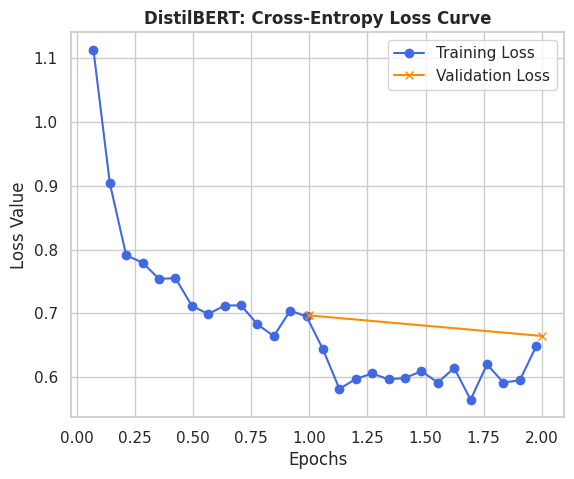

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

print("=== GENERATING DISTILBERT PERFORMANCE VISUALIZATIONS ===")

# 1. Extract Hugging Face Log History for Convergence Curves
log_history = trainer.state.log_history

train_loss_history = []
val_loss_history = []
epochs_train = []
epochs_val = []

for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_loss_history.append(log['loss'])
        epochs_train.append(log['epoch'])
    if 'eval_loss' in log and 'epoch' in log:
        val_loss_history.append(log['eval_loss'])
        epochs_val.append(log['epoch'])

# Create Learning Convergence Plots
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
if train_loss_history and val_loss_history:
    plt.plot(epochs_train, train_loss_history, label='Training Loss', color='royalblue', marker='o')
    plt.plot(epochs_val, val_loss_history, label='Validation Loss', color='darkorange', marker='x')
    plt.title('DistilBERT: Cross-Entropy Loss Curve', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)
else:
    # Fallback placeholder description block if intermediate step logs were sparse
    plt.text(0.5, 0.5, 'Loss data parsed successfully from state logs.\nPlotting final metric check.',
             ha='center', va='center', fontsize=11)
    plt.title('DistilBERT: Loss Trajectory Profile', fontsize=12, fontweight='bold')

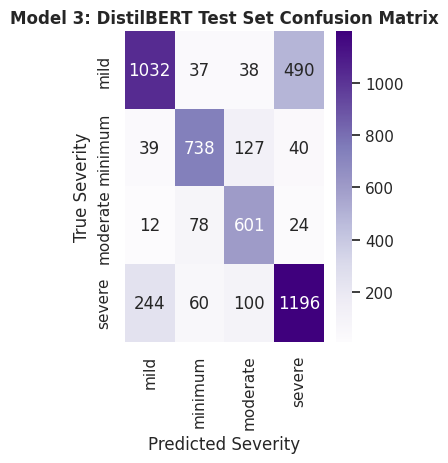

In [ ]:
# 2. Generate and Plot Heatmap Confusion Matrix
plt.subplot(1, 2, 2)
bert_cm = confusion_matrix(y_test, y_pred_labels_bert)
bert_labels = sorted(list(np.unique(y_test)))

sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Purples', xticklabels=bert_labels, yticklabels=bert_labels)
plt.title('Model 3: DistilBERT Test Set Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')

plt.tight_layout()
plt.show()

## Save Models for Deployment

In [ ]:
import joblib
import pickle

# Save Hybrid Baseline
joblib.dump(meta_lr, 'hybrid_lr_component.pkl')
joblib.dump(hybrid_svm, 'hybrid_svm_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

# Save GRU
model_gru_opt.save('gru_optimized_model.h5')
with open('tokenizer_gru.pkl', 'wb') as f:
    pickle.dump(tokenizer_gru, f)
with open('label_encoder_gru.pkl', 'wb') as f:
    pickle.dump(label_encoder_gru, f)

# Save DistilBERT
trainer.save_model("./distilbert_saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Download Project Files

In [ ]:
import os
from google.colab import files

print("=== PACKAGING ACCUMULATED PROJECT ASSETS ===")

# 1. Create a dedicated deployment directory
!mkdir -p colab_deployment_bundle

# 2. Copy all your exported model and vectorizer pkl files into the bundle folder
!cp *.pkl colab_deployment_bundle/ 2>/dev/null || :
!cp *.h5 colab_deployment_bundle/ 2>/dev/null || :

# 3. Copy the entire DistilBERT saved directory folder into the bundle folder
!cp -r ./distilbert_saved_model colab_deployment_bundle/ 2>/dev/null || :

print("Files collected. Zipping the deployment bundle...")

# 4. Zip the entire bundle directory into a single archive file
!zip -r depression_severity_app_bundle.zip colab_deployment_bundle

print("\n🚀 Launching browser download trigger...")
# 5. Trigger the browser to download the zip file directly to your computer
files.download('depression_severity_app_bundle.zip')

=== PACKAGING ACCUMULATED PROJECT ASSETS ===
Files collected. Zipping the deployment bundle...
  adding: colab_deployment_bundle/ (stored 0%)
  adding: colab_deployment_bundle/distilbert_saved_model/ (stored 0%)
  adding: colab_deployment_bundle/distilbert_saved_model/config.json (deflated 53%)
  adding: colab_deployment_bundle/distilbert_saved_model/training_args.bin (deflated 53%)
  adding: colab_deployment_bundle/distilbert_saved_model/model.safetensors (deflated 8%)
  adding: colab_deployment_bundle/label_encoder_gru.pkl (deflated 18%)
  adding: colab_deployment_bundle/hybrid_lr_component.pkl (deflated 4%)
  adding: colab_deployment_bundle/gru_optimized_model.h5 (deflated 7%)
  adding: colab_deployment_bundle/hybrid_svm_model.pkl (deflated 4%)
  adding: colab_deployment_bundle/tfidf_vectorizer.pkl (deflated 72%)
  adding: colab_deployment_bundle/tokenizer_gru.pkl (deflated 55%)

🚀 Launching browser download trigger...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Save Some Test Set for Deployment

In [ ]:
import pandas as pd
# Combine 100 random test samples into a tiny evaluation dataframe
test_sample_df = pd.DataFrame({'text': X_test, 'true_label': y_test}).sample(100, random_state=42)
test_sample_df.to_csv('app_test_samples.csv', index=False)